## Memory

Memory in LangGraph allows AI agents to remember and adapt based on previous interactions, enhancing efficiency and user satisfaction. This capability is essential for handling complex tasks and maintaining context across multiple user interactions.

There are two main types of memory in LangGraph:

- **Short-term memory** 

- **Long-term memory** 

## Example Short Term Memory

**Short-term memory:** Stores data within a single thread or session. It helps agents remember ongoing conversations and interactions within the current session, updating as the graph progresses through steps.

**Short-term memory** is especially useful for managing ongoing dialogue, ensuring the agent doesn’t forget recent user input while working within the limited context window of models.

    However, maintaining conversation history can become challenging in long sessions due to context limitations of LLMs (Large Language Models). Therefore, techniques like forgetting stale information or filtering are used to ensure the model works efficiently with long conversations.

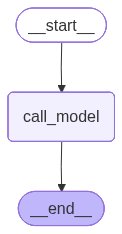

In [1]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage
# Define a simple model node

def call_model(state: MessagesState):
    last_user_message = state["messages"][-1].content
    response = AIMessage(content=f"You said: {last_user_message}")
    return {"messages": state["messages"] + [response]}
    
# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.set_entry_point("call_model")
builder.add_edge("call_model", END)
# Add short-term memory using in-memory checkpointer

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
# Invoke the graph with a thread ID
graph



In [2]:
graph.invoke(
    {"messages": [HumanMessage(content="Hi, I'm ABC")]},
    {"configurable": {"thread_id": "thread-1"}}
)

{'messages': [HumanMessage(content="Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='c371b222-866a-4673-95c5-a9e26466e956'),
  AIMessage(content="You said: Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='06bf7a8f-9421-408b-8f8c-1aaf76e21cbb')]}

In [3]:
graph.invoke(
    {"messages": [HumanMessage(content="I want to learn ML")]},
    {"configurable": {"thread_id": "thread-1"}}
)

{'messages': [HumanMessage(content="Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='c371b222-866a-4673-95c5-a9e26466e956'),
  AIMessage(content="You said: Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='06bf7a8f-9421-408b-8f8c-1aaf76e21cbb'),
  HumanMessage(content='I want to learn ML', additional_kwargs={}, response_metadata={}, id='557546a5-93bc-4586-b4a3-59ba3f106acd'),
  AIMessage(content='You said: I want to learn ML', additional_kwargs={}, response_metadata={}, id='6c2b4a97-5c88-45c0-848f-76ea4caf2f96')]}

In [4]:
graph.invoke(
    {"messages": [HumanMessage(content="I want to learn AI and ML")]},
    {"configurable": {"thread_id": "thread-1"}}
)

{'messages': [HumanMessage(content="Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='c371b222-866a-4673-95c5-a9e26466e956'),
  AIMessage(content="You said: Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='06bf7a8f-9421-408b-8f8c-1aaf76e21cbb'),
  HumanMessage(content='I want to learn ML', additional_kwargs={}, response_metadata={}, id='557546a5-93bc-4586-b4a3-59ba3f106acd'),
  AIMessage(content='You said: I want to learn ML', additional_kwargs={}, response_metadata={}, id='6c2b4a97-5c88-45c0-848f-76ea4caf2f96'),
  HumanMessage(content='I want to learn AI and ML', additional_kwargs={}, response_metadata={}, id='11b0c4ad-3bef-484d-a88c-7fa848a4725f'),
  AIMessage(content='You said: I want to learn AI and ML', additional_kwargs={}, response_metadata={}, id='77e3d0f6-1953-4a01-bb99-488005c4ac02')]}

## Example 2

In [5]:
import time
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.store.base import BaseStore
from langgraph.graph import START, MessagesState, StateGraph, END
from langchain_aws import ChatBedrockConverse
from langgraph.checkpoint.memory import InMemorySaver

#  Configuration (Bedrock LLM Setup) ---
model = ChatBedrockConverse(
    model_id="anthropic.claude-3-sonnet-20240229-v1:0",  # Replace with the actual Bedrock LLM model ID
    region_name="us-east-1",  # Region where Bedrock is available
    temperature=0.4,
    max_tokens=100
)

# Define the Chatbot Interaction ---
def chat(state: MessagesState) -> dict:
    """
    Handles the user message, processes it, and invokes the Bedrock LLM to generate a response.
    """
    
    # ----------------------------------------------------
    # Prepare the system prompt for Bedrock model
    # ----------------------------------------------------
    system_prompt = (
        "You are a helpful, ethical, and conservative **Financial Advisor AI**. "
        "Use the user's message to provide professional, financial advice. "
        "Keep your answers focused on financial well-being."
        "You can refer previous conversations to answer user queries if required."
    )

    # ----------------------------------------------------
    # Step C: Invoke the Bedrock LLM for a response
    # ----------------------------------------------------
    response = model.invoke(
        [
            {"role": "system", "content": system_prompt},
            *state["messages"],  # Include the user message in the context
        ]
    )

    # ----------------------------------------------------
    # Step D: Return the response from the LLM
    # ----------------------------------------------------
    return {"messages": [response]}

#  Build the Graph ---
builder = StateGraph(MessagesState)
builder.add_node("chat_node", chat)  # Add chat logic to the graph
builder.add_edge(START, "chat_node")  # Connect start to the chat node
builder.add_edge("chat_node", END)    # Connect chat node to the end

# Compile the Graph with InMemorySaver ---
graph = builder.compile(checkpointer=InMemorySaver())  # Use InMemorySaver for state checkpointing



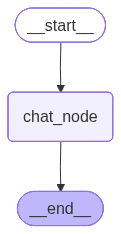

In [6]:
graph

In [7]:
from rich import print

while True:
    # Get user input and thread_id
    user_input = input("User: ")
    if user_input.lower() in ['exit', 'quit', 'bye']:
        print("Chatbot has ended.")
        break

    thread_id = input("Thread ID: ")

    # Create the message and config for graph.stream
    messages = [{"role": "user", "content": user_input}]  # Ensure the first message is from the user
    config = {"configurable": {"thread_id": thread_id}}  # Config for thread_id
    # Using graph.stream with the correct structure
    for step in graph.stream({"messages": messages}, config=config):
        # Print AI's response (assuming step contains the response)
        print(step)  # Get the AI's response content


User:  Hi
Thread ID:  1


{
    'chat_node': {
        'messages': [
            AIMessage(
                content="Hello! I'm Claude, an AI assistant specializing in financial advice. How can I help you 
with any personal finance or investment-related questions you may have? I'll do my best to provide ethical and 
conservative guidance to support your financial well-being.",
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': 'b38a8f6f-55c1-43f3-90f6-628446daf52e',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 16 Mar 2026 03:58:03 GMT',
                            'content-type': 'application/json',
                            'content-length': '462',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': 'b38a8f6f-55c1-43f3-90f6-628446daf52e'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'end_turn',
                    'metrics': {'latencyMs': [1214]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--26502ee3-91c1-463b-99bd-59b53485226b-0',
                usage_metadata={
                    'input_tokens': 58,
                    'output_tokens': 55,
                    'total_tokens': 113,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

User:  I want to learn how to invest
Thread ID:  1


{
    'chat_node': {
        'messages': [
            AIMessage(
                content='Here are some tips for learning how to invest as a beginner:\n\n1. Understand the 
different types of investments - stocks, bonds, mutual funds, ETFs, etc. Read up on how each one works and their 
potential risks/rewards.\n\n2. Start with your goals - Are you investing for retirement, a home purchase, education
expenses? Your goals will help determine your investment strategy.\n\n3. Learn about asset allocation and 
diversification. Having a diversified portfolio across different asset',
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '84b100a6-6649-411d-9e22-0cf9fa238189',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 16 Mar 2026 03:58:22 GMT',
                            'content-type': 'application/json',
                            'content-length': '695',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '84b100a6-6649-411d-9e22-0cf9fa238189'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'max_tokens',
                    'metrics': {'latencyMs': [1808]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--f38851af-5146-4a98-81ff-93b38337f808-0',
                usage_metadata={
                    'input_tokens': 123,
                    'output_tokens': 100,
                    'total_tokens': 223,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

User:  exit


Chatbot has ended.

In [8]:
config = {"configurable": {"thread_id": "1"}} 
print(list(graph.get_state_history(config)))

[
    StateSnapshot(
        values={
            'messages': [
                HumanMessage(
                    content='Hi',
                    additional_kwargs={},
                    response_metadata={},
                    id='e7eb88c8-99d8-4781-9d39-27a8b7ded249'
                ),
                AIMessage(
                    content="Hello! I'm Claude, an AI assistant specializing in financial advice. How can I help 
you with any personal finance or investment-related questions you may have? I'll do my best to provide ethical and 
conservative guidance to support your financial well-being.",
                    additional_kwargs={},
                    response_metadata={
                        'ResponseMetadata': {
                            'RequestId': 'b38a8f6f-55c1-43f3-90f6-628446daf52e',
                            'HTTPStatusCode': 200,
                            'HTTPHeaders': {
                                'date': 'Mon, 16 Mar 2026 03:58:03 GMT',
                                'content-type': 'application/json',
                                'content-length': '462',
                                'connection': 'keep-alive',
                                'x-amzn-requestid': 'b38a8f6f-55c1-43f3-90f6-628446daf52e'
                            },
                            'RetryAttempts': 0
                        },
                        'stopReason': 'end_turn',
                        'metrics': {'latencyMs': [1214]},
                        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                    },
                    id='run--26502ee3-91c1-463b-99bd-59b53485226b-0',
                    usage_metadata={
                        'input_tokens': 58,
                        'output_tokens': 55,
                        'total_tokens': 113,
                        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                    }
                ),
                HumanMessage(
                    content='I want to learn how to invest',
                    additional_kwargs={},
                    response_metadata={},
                    id='c48a7982-fc1e-46cd-af81-57e0d9ddde21'
                ),
                AIMessage(
                    content='Here are some tips for learning how to invest as a beginner:\n\n1. Understand the 
different types of investments - stocks, bonds, mutual funds, ETFs, etc. Read up on how each one works and their 
potential risks/rewards.\n\n2. Start with your goals - Are you investing for retirement, a home purchase, education
expenses? Your goals will help determine your investment strategy.\n\n3. Learn about asset allocation and 
diversification. Having a diversified portfolio across different asset',
                    additional_kwargs={},
                    response_metadata={
                        'ResponseMetadata': {
                            'RequestId': '84b100a6-6649-411d-9e22-0cf9fa238189',
                            'HTTPStatusCode': 200,
                            'HTTPHeaders': {
                                'date': 'Mon, 16 Mar 2026 03:58:22 GMT',
                                'content-type': 'application/json',
                                'content-length': '695',
                                'connection': 'keep-alive',
                                'x-amzn-requestid': '84b100a6-6649-411d-9e22-0cf9fa238189'
                            },
                            'RetryAttempts': 0
                        },
                        'stopReason': 'max_tokens',
                        'metrics': {'latencyMs': [1808]},
                        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                    },
                    id='run--f38851af-5146-4a98-81ff-93b38337f808-0',
                    usage_metadata={
                        'input_tokens': 123,
                        'output_tokens': 100,
                        'total_tokens': 223,
                        'input

In [9]:
from rich import print

while True:
    # Get user input and thread_id
    user_input = input("User: ")
    if user_input.lower() in ['exit', 'quit', 'bye']:
        print("Chatbot has ended.")
        break

    thread_id = input("Thread ID: ")

    # Create the message and config for graph.stream
    messages = [{"role": "user", "content": user_input}]  # Ensure the first message is from the user
    config = {"configurable": {"thread_id": thread_id}}  # Config for thread_id
    # Using graph.stream with the correct structure
    for step in graph.stream({"messages": messages}, config=config):
        # Print AI's response (assuming step contains the response)
        print(step)  # Get the AI's response content

User:  hi
Thread ID:  2


{
    'chat_node': {
        'messages': [
            AIMessage(
                content="Hello! I'm Claude, an AI assistant created by Anthropic to provide helpful financial 
advice. How can I assist you today with any questions or topics related to personal finance, investing, budgeting, 
retirement planning, or general financial well-being? I'll do my best to offer prudent and ethical guidance 
tailored to your specific situation and goals.",
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '01ca841b-4b65-4d40-b6c0-f70fd74b6bb3',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 16 Mar 2026 03:58:45 GMT',
                            'content-type': 'application/json',
                            'content-length': '558',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '01ca841b-4b65-4d40-b6c0-f70fd74b6bb3'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'end_turn',
                    'metrics': {'latencyMs': [1546]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--685d3ca4-d550-460a-ad23-2a107e2fc798-0',
                usage_metadata={
                    'input_tokens': 58,
                    'output_tokens': 76,
                    'total_tokens': 134,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

User:  want to learn english
Thread ID:  2


{
    'chat_node': {
        'messages': [
            AIMessage(
                content="I don't actually provide language learning assistance directly. As an AI assistant focused
on financial advice, my knowledge is centered around topics like personal finance, investing, budgeting, retirement
planning and general financial well-being. \n\nHowever, I can provide some general tips that may be helpful if 
you're looking to improve your English skills:\n\n1) Practice regularly through reading, writing, listening to 
audio/video in English, and conversing with others when possible.\n\n2) Use language learning",
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '15bff92a-e573-4daa-aee2-27531b6658b8',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 16 Mar 2026 03:59:00 GMT',
                            'content-type': 'application/json',
                            'content-length': '730',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '15bff92a-e573-4daa-aee2-27531b6658b8'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'max_tokens',
                    'metrics': {'latencyMs': [2117]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--ed325a6f-862e-4395-a9b8-46cd9e51e9c0-0',
                usage_metadata={
                    'input_tokens': 141,
                    'output_tokens': 100,
                    'total_tokens': 241,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

User:  exit


Chatbot has ended.

In [10]:
config = {"configurable": {"thread_id": "2"}} 
print(list(graph.get_state_history(config)))

[
    StateSnapshot(
        values={
            'messages': [
                HumanMessage(
                    content='hi',
                    additional_kwargs={},
                    response_metadata={},
                    id='e621e4bd-49b9-4143-a141-bdddfa988ed2'
                ),
                AIMessage(
                    content="Hello! I'm Claude, an AI assistant created by Anthropic to provide helpful financial 
advice. How can I assist you today with any questions or topics related to personal finance, investing, budgeting, 
retirement planning, or general financial well-being? I'll do my best to offer prudent and ethical guidance 
tailored to your specific situation and goals.",
                    additional_kwargs={},
                    response_metadata={
                        'ResponseMetadata': {
                            'RequestId': '01ca841b-4b65-4d40-b6c0-f70fd74b6bb3',
                            'HTTPStatusCode': 200,
                            'HTTPHeaders': {
                                'date': 'Mon, 16 Mar 2026 03:58:45 GMT',
                                'content-type': 'application/json',
                                'content-length': '558',
                                'connection': 'keep-alive',
                                'x-amzn-requestid': '01ca841b-4b65-4d40-b6c0-f70fd74b6bb3'
                            },
                            'RetryAttempts': 0
                        },
                        'stopReason': 'end_turn',
                        'metrics': {'latencyMs': [1546]},
                        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                    },
                    id='run--685d3ca4-d550-460a-ad23-2a107e2fc798-0',
                    usage_metadata={
                        'input_tokens': 58,
                        'output_tokens': 76,
                        'total_tokens': 134,
                        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                    }
                ),
                HumanMessage(
                    content='want to learn english',
                    additional_kwargs={},
                    response_metadata={},
                    id='0b2ba9ab-b085-44d5-bbc7-76e1fe6be828'
                ),
                AIMessage(
                    content="I don't actually provide language learning assistance directly. As an AI assistant 
focused on financial advice, my knowledge is centered around topics like personal finance, investing, budgeting, 
retirement planning and general financial well-being. \n\nHowever, I can provide some general tips that may be 
helpful if you're looking to improve your English skills:\n\n1) Practice regularly through reading, writing, 
listening to audio/video in English, and conversing with others when possible.\n\n2) Use language learning",
                    additional_kwargs={},
                    response_metadata={
                        'ResponseMetadata': {
                            'RequestId': '15bff92a-e573-4daa-aee2-27531b6658b8',
                            'HTTPStatusCode': 200,
                            'HTTPHeaders': {
                                'date': 'Mon, 16 Mar 2026 03:59:00 GMT',
                                'content-type': 'application/json',
                                'content-length': '730',
                                'connection': 'keep-alive',
                                'x-amzn-requestid': '15bff92a-e573-4daa-aee2-27531b6658b8'
                            },
                            'RetryAttempts': 0
                        },
                        'stopReason': 'max_tokens',
                        'metrics': {'latencyMs': [2117]},
                        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                    },
                    id='run--ed325a6f-862e-4395-a9b8-46cd9e51e9c0-0',
                    usage_metadata={
                        'input_tokens': 1